In [3]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings


warnings.filterwarnings("ignore")

In [ ]:
#bet = companise file which is base_etablissement_par_tranche_effectif
bet =pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_base_etablissement.csv')


#ngi= name_geographic_information.csv
ngi =pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_geographic_information.csv')

#nts= net_salary_per_town_categories.csv
nts =pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_net_salary_per_town.csv')

#ppl = population.csv
ppl=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_population.csv')


In [ ]:
#####################################################################################################################################

In [ ]:
#bet = companise file which is base_etablissement_par_tranche_effectif
bet =pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_base_etablissement.csv')
bet.head()

In [ ]:
pd.set_option('display.max_columns', None)
display(bet)

In [ ]:
# Check for missing values and display them
missing_values = bet.isnull().sum()* 100 / len(bet)
print(missing_values)

CODGEO                                0.0
LIBGEO                                0.0
REG                                   0.0
DEP                                   0.0
Total businesses in the city          0.0
businesses of unknown or zero size    0.0
1 to 5 employees                      0.0
6 to 9 employees                      0.0
10 to 19 employees                    0.0
20 to 49 employees                    0.0
50 to 99 employees                    0.0
100 to 199 employees                  0.0
200 to 499 employees                  0.0
>500 employees                        0.0
dtype: float64


In [ ]:
#####################################################################################################################################

In [ ]:

#ngi= name_geographic_information.csv
ngi =pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_geographic_information.csv')
ngi.head()


,REG,Region_Name,Regional_Capital,DEP,Con_Number,Commune_Name,Postal_Codes,INSEE_Code,Distance
0,82,Rhône-Alpes,Lyon,01,1,Attignat,01340,1024,1.21
1,82,Rhône-Alpes,Lyon,01,1,Beaupont,01270,1029,1.91
2,82,Rhône-Alpes,Lyon,01,1,Bény,01370,1038,1.51
3,82,Rhône-Alpes,Lyon,01,1,Béreyziat,01340,1040,1.71
4,82,Rhône-Alpes,Lyon,01,1,Bohas-Meyriat-Rignat,01250,1245,1.01


In [ ]:
ngi.info()

In [ ]:
# Define and change the column names in English to be more undersandable

english_names = [
                 "REG",
                 "Region_Name",
                 "Regional_Capital",
                 "DEP",
                 "Con_Number",
                 "Commune_Name",
                 "Postal_Codes",
                 "INSEE_Code",
                 "Distance"
]

# Assign the new column names to the DataFrame
ngi.columns = english_names

# Display the DataFrame with the updated column names
display(ngi)

,REG,Region_Name,Regional_Capital,DEP,Con_Number,Commune_Name,Postal_Codes,INSEE_Code,Distance
0,82,Rhône-Alpes,Lyon,01,1,Attignat,01340,1024,1.210000
1,82,Rhône-Alpes,Lyon,01,1,Beaupont,01270,1029,1.910000
2,82,Rhône-Alpes,Lyon,01,1,Bény,01370,1038,1.510000
3,82,Rhône-Alpes,Lyon,01,1,Béreyziat,01340,1040,1.710000
4,82,Rhône-Alpes,Lyon,01,1,Bohas-Meyriat-Rignat,01250,1245,1.010000
...,...,...,...,...,...,...,...,...,...
36835,5,Mayotte,Mamoudzou,976,1,M'TSANGAMOUJI,97600,97613,1.471278
36836,5,Mayotte,Mamoudzou,976,1,OUANGANI,97600,97614,1.471278
36837,5,Mayotte,Mamoudzou,976,1,PAMANDZI,97610,97615,1.471278
36838,5,Mayotte,Mamoudzou,976,1,SADA,97640,97616,1.471278


In [ ]:
#check the data types of each column
print(ngi.dtypes)

REG                   int64
Region_Name          object
Regional_Capital     object
DEP                  object
Con_Number            int64
Commune_Name         object
Postal_Codes         object
INSEE_Code            int64
Distance            float64
dtype: object


In [ ]:
# Check for missing values and display them
missing_values = ngi.isnull().sum()* 100 / len(ngi)
print(missing_values)




REG                 0.0
Region_Name         0.0
Regional_Capital    0.0
DEP                 0.0
Con_Number          0.0
Commune_Name        0.0
Postal_Codes        0.0
INSEE_Code          0.0
Distance            0.0
dtype: float64


In [ ]:
#To fix the missing values in Latitude 8% ,Longitude 7.7% ,Distance 8% of missing values
#the code here is you did use it to clean the missing values.

# Group by a relevant geographic attribute (as Region_Name) and impute missing values with the mean
ngi['Latitude'] = ngi.groupby('Region_Name')['Latitude'].transform(lambda x: x.fillna(x.mean()))

# Convert the "Longitude" column to numeric
ngi['Longitude'] = pd.to_numeric(ngi['Longitude'], errors='coerce')

# Group by 'Region_Name' and impute missing values with the mean
ngi['Longitude'] = ngi.groupby('Region_Name')['Longitude'].transform(lambda x: x.fillna(x.mean()))

# We still have 132 of missing values for both Latitue and Longitude so we fill them with mean.
ngi['Latitude'].fillna(ngi['Latitude'].mean(), inplace=True)
ngi['Longitude'].fillna(ngi['Longitude'].mean(), inplace=True)

# Impute missing values in 'Distance' with the mean
ngi['Distance'].fillna(ngi['Distance'].mean(), inplace=True)

# Display the updated DataFrame
print(ngi)



In [ ]:
#to confer that there are not missing values
ngi.isna().sum()

In [ ]:
duplicates = ngi.duplicated()

# Count the number of duplicate rows
num_duplicates = duplicates.sum()

# Display the duplicate rows, if any
duplicate_rows = ngi[duplicates]
print("Number of duplicate rows:", num_duplicates)
print("Duplicate rows:")
print(duplicate_rows)

In [ ]:
# having descriptive statistics for each column in the ngi DataFrame
ngi_statistics = ngi.describe()

# Round the statistics to two decimal places
ngi_statistics = ngi_statistics.round(2)

# Display the descriptive statistics
print(ngi_statistics)

In [ ]:
# the columns that we do not need to be the dataset we have removed them
# List of columns to drop
columns_to_drop = ["Eu_Con", "Department_Name", "Prefecture", "Latitude", "Longitude"]

# Drop the specified columns
ngi = ngi.drop(columns=columns_to_drop)
################################################################################################
# Save the DataFrame to a CSV file with an absolute path
ngi.to_csv('/content/drive/MyDrive/Project_(french_industry)/updated_geographic_information.csv', index=False)

# Provide a download link to the saved file
from google.colab import files
files.download('/content/drive/MyDrive/Project_(french_industry)/updated_geographic_information.csv')


In [ ]:
#####################################################################################################################################

In [ ]:
#nts= net_salary_per_town_categories.csv
nts =pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_net_salary_per_town.csv')
nts.head()

,Unnamed: 0,CODGEO,LIBGEO,avg,executive,middle_manager,employee,worker,avg_f,executive_f,...,worker_m,avg_18,avg_26,avg_51,18_f,26_f,51_f,18_m,26_m,51_m
0,0,01004,Ambérieu-en-Bugey,13.7,24.2,15.5,10.3,11.2,11.6,19.1,...,11.6,10.5,13.7,16.1,9.7,11.8,12.5,11.0,14.9,18.6
1,1,01007,Ambronay,13.5,22.1,14.7,10.7,11.4,11.9,19.0,...,11.7,9.8,13.8,14.6,9.2,12.2,12.5,10.2,14.9,16.4
2,2,01014,Arbent,13.5,27.6,15.6,11.1,11.1,10.9,19.5,...,11.8,9.3,13.3,16.0,8.9,10.6,12.5,9.6,15.1,18.6
3,3,01024,Attignat,12.9,21.8,14.1,11.0,11.3,11.4,19.0,...,11.6,9.6,12.9,14.2,9.3,11.4,12.2,9.7,13.8,15.9
4,4,01025,Bâgé-la-Ville,13.0,22.8,14.1,10.5,11.1,11.6,19.4,...,11.4,9.4,12.8,15.2,9.0,11.8,12.3,9.7,13.4,16.9


In [ ]:
# Check for missing values and display them
missing_values = nts.isnull().sum()* 100 / len(nts)
print(missing_values)

Unnamed: 0          0.0
CODGEO              0.0
LIBGEO              0.0
avg                 0.0
executive           0.0
middle_manager      0.0
employee            0.0
worker              0.0
avg_f               0.0
executive_f         0.0
middle_manager_f    0.0
employee_f          0.0
worker_f            0.0
avg_m               0.0
executive_m         0.0
middle_manager_m    0.0
employee_m          0.0
worker_m            0.0
avg_18              0.0
avg_26              0.0
avg_51              0.0
18_f                0.0
26_f                0.0
51_f                0.0
18_m                0.0
26_m                0.0
51_m                0.0
dtype: float64


In [ ]:
duplicates = nts.duplicated()

# Count the number of duplicate rows
num_duplicates = duplicates.sum()

# Display the duplicate rows, if any
duplicate_rows = nts[duplicates]
print("Number of duplicate rows:", num_duplicates)
print("Duplicate rows:")
print(duplicate_rows)

In [1]:
# To remove unneeded column that does not present anything
nts=nts.drop(columns=[unnamed: 0])
nts.head




SyntaxError: invalid syntax (<ipython-input-1-03ae9940d22b>, line 2)

In [ ]:
#####################################################################################################################################

In [5]:
#ppl = population.csv
ppl=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/updated_population.csv')
ppl.head()

,CODGEO,LIBGEO,MOCH,AGEB0_80,SEXE,NPC
0,1001,L'Abergement-Clémenciat,11,0,1,15
1,1001,L'Abergement-Clémenciat,11,0,2,15
2,1001,L'Abergement-Clémenciat,11,5,1,20
3,1001,L'Abergement-Clémenciat,11,5,2,20
4,1001,L'Abergement-Clémenciat,11,10,1,20


In [ ]:
# Define and change the column names in English to be more undersandable

new_names = ['Geo_level', 'CODGEO', 'LIBGEO', 'MOCH', 'AGEB0_80', 'SEXE', 'NPC'
]

# Assign the new column names to the DataFrame
ppl.columns = new_names

# Display the DataFrame with the updated column names
display(ppl.head())

In [ ]:
# drop unneeded column
ppl = ppl.drop(columns=['Geo_level'])


# Save the DataFrame to a CSV file in your Colab environment
ppl.to_csv('updated_population.csv', index=False)

# Provide a download link to the saved file
from google.colab import files
files.download('updated_population.csv')

In [ ]:
print(ppl.dtypes)

In [ ]:
ppl.isna().sum()

In [ ]:
# Check for duplicates in a DataFrame
duplicates = ppl.duplicated()

# Count the number of duplicate rows
num_duplicates = duplicates.sum()

# Display the duplicate rows, if any
duplicate_rows = ppl[duplicates]
print("Number of duplicate rows:", num_duplicates)
print("Duplicate rows:")
print(duplicate_rows)


In [ ]:
# having descriptive statistics for each column in the ngi DataFrame
ppl_statistics = ppl.describe()

# Round the statistics to two decimal places
ppl_statistics = ppl_statistics.round(2)

# Display the descriptive statistics
print(ppl_statistics)

In [ ]:
# Group the data by 'CODGEO' and 'MOCH' and calculate the mean of 'NB'
average_people_in_household = ppl.groupby(['CODGEO', 'MOCH'])['NPC'].mean().reset_index().round(2)
# Print the average number of people in one household
print(average_people_in_household)

In [ ]:
ppl['MOCH'] = ppl['MOCH'].astype(str)
# Group the data by 'CODGEO' and 'MOCH' and calculate the mean of 'NB'
average_people_in_household = ppl.groupby(['CODGEO', 'MOCH'])['NPC'].mean().reset_index()

# Print the average number of people in one household
print(average_people_in_household)


In [ ]:
ppl.info()


In [ ]:

# Get the names of all columns

bet_column_names = bet.columns
print("Column names for 'bet' dataset:", bet_column_names)

ngi_column_names = ngi.columns

print("Column names for 'ngi' dataset:", ngi_column_names)
nts_column_names = nts.columns

print("Column names for 'nts' dataset:", nts_column_names)

ppl_column_names = ppl.columns
print("Column names for 'ppl' dataset:", ppl_column_names)


In [ ]:
# Filter the data for Paris so we can do some graphis
paris_data = nts[nts['LIBGEO'].str.contains('Paris', case=False)]
paris_data.head(10)

,Unnamed: 0,CODGEO,LIBGEO,avg,executive,middle_manager,employee,worker,avg_f,executive_f,...,worker_m,avg_18,avg_26,avg_51,18_f,26_f,51_f,18_m,26_m,51_m
1808,1808,38485,Seyssinet-Pariset,14.5,23.8,14.6,10.8,11.5,12.9,21.0,...,11.7,9.8,14.2,17.3,9.5,12.8,14.6,10.0,15.2,19.2
1835,1835,39189,Damparis,13.3,23.4,15.8,10.3,12.5,10.5,16.7,...,13.3,9.3,13.1,15.4,8.8,10.6,11.0,9.7,14.5,17.5
3211,3211,62826,Le Touquet-Paris-Plage,16.7,33.0,14.7,10.6,11.8,13.6,25.1,...,12.2,9.3,13.6,25.2,8.6,11.8,18.4,9.8,15.1,31.0
3923,3923,75056,Paris,22.2,31.9,17.2,12.3,13.2,19.1,26.7,...,13.3,11.8,21.7,28.3,11.4,19.5,21.8,12.2,23.5,33.8
4138,4138,77514,Villeparisis,14.2,23.0,15.3,11.5,12.1,13.2,20.5,...,12.3,10.2,14.2,16.7,9.9,13.3,15.0,10.5,14.8,17.8
4989,4989,95176,Cormeilles-en-Parisis,17.9,26.2,16.6,12.5,12.6,16.2,23.6,...,12.8,10.4,17.6,21.5,9.8,16.2,18.7,11.0,18.6,23.4


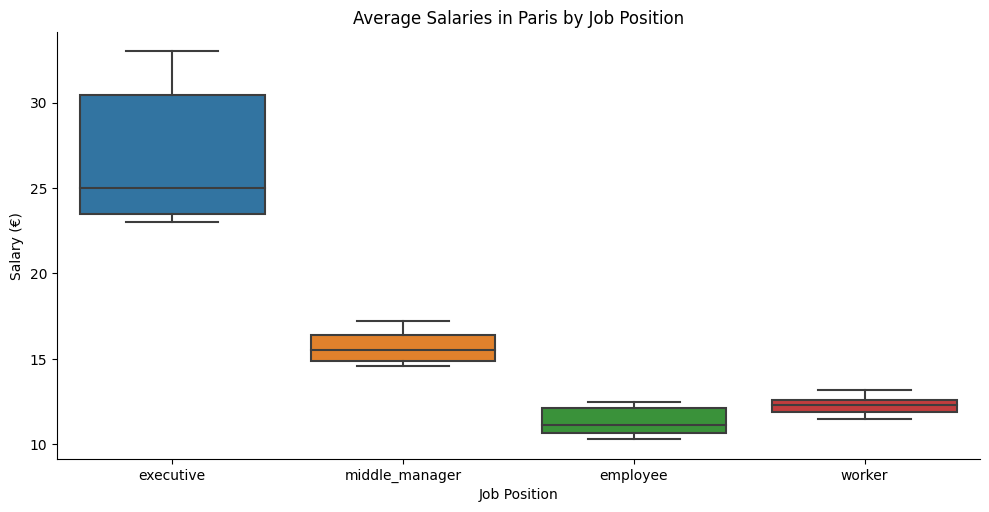

Average Salaries in Paris
      executive  middle_manager  employee  worker
1808       23.8            14.6      10.8    11.5
1835       23.4            15.8      10.3    12.5
3211       33.0            14.7      10.6    11.8
3923       31.9            17.2      12.3    13.2
4138       23.0            15.3      11.5    12.1
4989       26.2            16.6      12.5    12.6


In [ ]:
# Here Average Salaries in Paris by Job Position


# Data for average salaries
average_salaries = paris_data[['executive', 'middle_manager', 'employee', 'worker']]

# Create a DataFrame for catplot
data = average_salaries.melt(var_name='Job Position', value_name='Salary')

# Create the catplot
sns.catplot(x='Job Position', y='Salary', kind='box', data=data, height=5, aspect=2)
plt.title('Average Salaries in Paris by Job Position')
plt.xlabel('Job Position')
plt.ylabel('Salary (€)')
plt.show()
# Print the average salaries for all job categories
print("Average Salaries in Paris")
print(average_salaries.round(2))



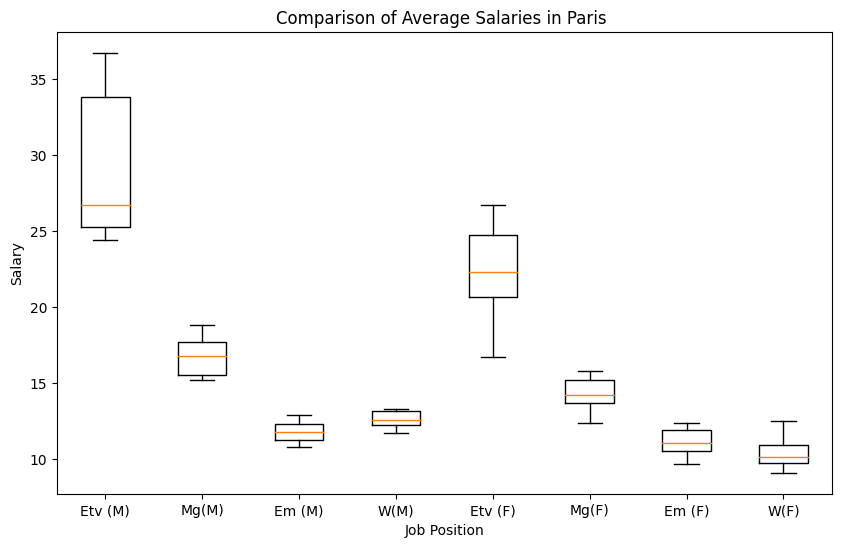

Average Salaries for Male
      executive_m  middle_manager_m  employee_m  worker_m
1808         25.1              15.2        11.1      11.7
1835         25.6              17.6        11.9      13.3
3211         36.7              15.4        10.8      12.2
3923         35.8              18.8        12.4      13.3
4138         24.4              15.9        11.6      12.3
4989         27.8              17.7        12.9      12.8
Average Salaries for Female
      executive_f  middle_manager_f  employee_f  worker_f
1808         21.0              13.6        10.7      10.1
1835         16.7              12.4         9.7       9.6
3211         25.1              13.9        10.5       9.1
3923         26.7              15.8        12.1      12.5
4138         20.5              14.5        11.4      10.2
4989         23.6              15.4        12.4      11.2


In [ ]:
# Here we have Comparison of Average Salaries in Paris

# Data for average salaries
average_salaries = paris_data[['executive', 'middle_manager', 'employee', 'worker']]
average_salary_m = paris_data[['executive_m', 'middle_manager_m', 'employee_m', 'worker_m']]
average_salary_f = paris_data[['executive_f', 'middle_manager_f', 'employee_f', 'worker_f']]


# Transpose the data to have salary on the y-axis
data = [average_salary_m['executive_m'], average_salary_m['middle_manager_m'],
        average_salary_m['employee_m'], average_salary_m['worker_m'],
        average_salary_f['executive_f'], average_salary_f['middle_manager_f'],
        average_salary_f['employee_f'], average_salary_f['worker_f']]
labels = ['Etv (M)', 'Mg(M)', 'Em (M)', 'W(M)',
          'Etv (F)', 'Mg(F)', 'Em (F)', 'W(F)']

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=labels, vert=True)
plt.title('Comparison of Average Salaries in Paris ')
plt.xlabel('Job Position')
plt.ylabel('Salary')

plt.show()


# Print the average salaries for males and females in each job position
print("Average Salaries for Male")
print(average_salary_m.round(2))
print("Average Salaries for Female")
print(average_salary_f.round(2))

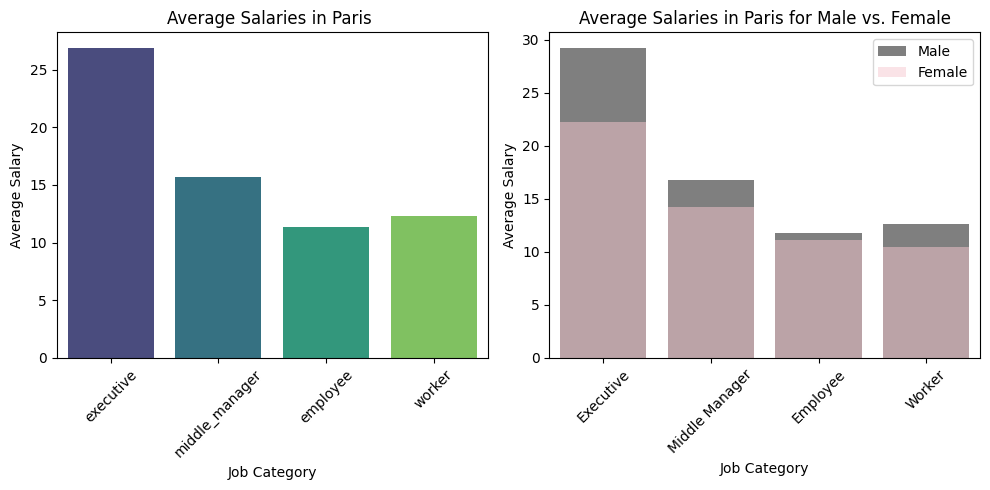

Average Salaries in Paris
executive         26.88
middle_manager    15.70
employee          11.33
worker            12.28
dtype: float64
Average Salaries for Male
executive_m         29.23
middle_manager_m    16.77
employee_m          11.78
worker_m            12.60
dtype: float64
Average Salaries for Female
executive_f         22.27
middle_manager_f    14.27
employee_f          11.13
worker_f            10.45
dtype: float64


In [ ]:
# Filter the data for Paris
paris_data = nts[nts['LIBGEO'].str.contains('Paris', case=False)]

# Calculate the average salaries
average_salaries = paris_data[['executive', 'middle_manager', 'employee', 'worker']].mean()

# Calculate the average salaries for males and females in each job position
average_salary_m = paris_data[['executive_m', 'middle_manager_m', 'employee_m', 'worker_m']].mean()
average_salary_f = paris_data[['executive_f', 'middle_manager_f', 'employee_f', 'worker_f']].mean()

# Create a single figure and subplots
fig1, axes1 = plt.subplots(1, 2, figsize=(10, 5))

# Create first bar plot for all average salaries
sns.barplot(x=average_salaries.index, y=average_salaries.values, palette="viridis", ax=axes1[0])
axes1[0].set_title("Average Salaries in Paris ")
axes1[0].set_xlabel("Job Category")
axes1[0].set_ylabel("Average Salary")
axes1[0].tick_params(axis='x', rotation=45)

# Create a bar plot to compare male and female
positions = ["Executive", "Middle Manager", "Employee", "Worker"]  # Define the position names
sns.barplot(x=positions, y=average_salary_m.values, color='black', label='Male', alpha=0.5, ax=axes1[1])
sns.barplot(x=positions, y=average_salary_f.values, color='pink', label='Female', alpha=0.5, ax=axes1[1])
axes1[1].set_title("Average Salaries in Paris for Male vs. Female")
axes1[1].set_xlabel("Job Category")
axes1[1].set_ylabel("Average Salary")
axes1[1].tick_params(axis='x', rotation=45)
axes1[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print the average salaries for all job categories
print("Average Salaries in Paris")
print(average_salaries.round(2))

# Print the average salaries for males and females in each job position
print("Average Salaries for Male")
print(average_salary_m.round(2))
print("Average Salaries for Female")
print(average_salary_f.round(2))

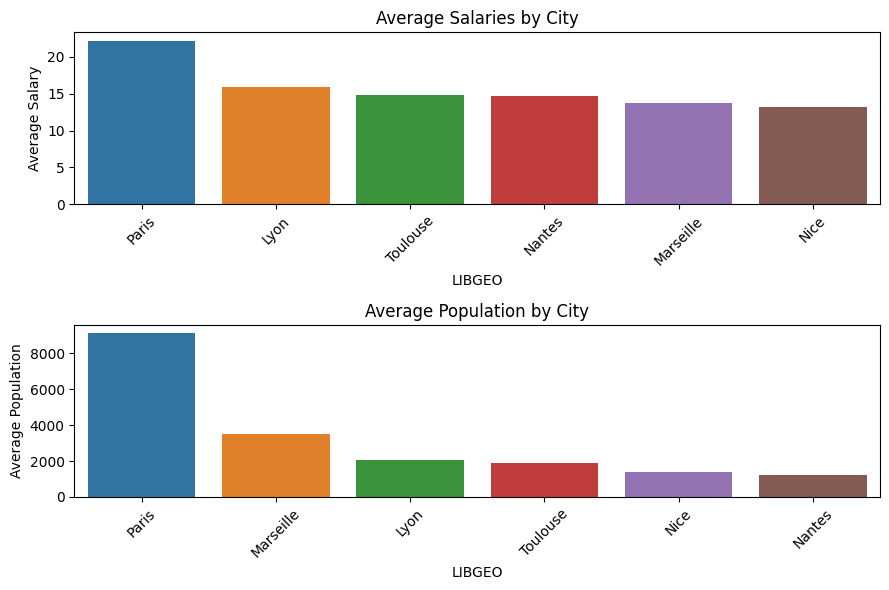

Average Salaries by City
            avg
LIBGEO         
Paris      22.2
Lyon       15.9
Toulouse   14.8
Nantes     14.7
Marseille  13.8
Nice       13.2
Average Population by City
      LIBGEO      NPC
4      Paris  9131.42
1  Marseille  3504.78
0       Lyon  2064.95
5   Toulouse  1914.07
3       Nice  1407.27
2     Nantes  1213.80


In [ ]:
# Print the average salaries for all selected cities And  the average population for all selected cities:


# List of cities to compare
cities_to_compare = ['Paris', 'Marseille', 'Lyon', 'Toulouse', 'Nice', 'Nantes']

# Filter population data for the selected cities
selected_population_data = ppl[ppl['LIBGEO'].isin(cities_to_compare)]

# Filter salary data for the selected cities
selected_salary_data = nts[nts['LIBGEO'].isin(cities_to_compare)]

# Calculate the average salaries for each city (Target)
average_salaries_by_city = selected_salary_data.groupby('LIBGEO')[['avg']].mean()

# Calculate the average population for each city (Target)
average_population_by_city = selected_population_data.groupby('LIBGEO')['NPC'].mean().reset_index().round(2)

# Create subplots for comparison
fig, axes = plt.subplots(2, 1, figsize=(9, 6))

# Sort the data in descending order by 'avg' column for average salaries
average_salaries_by_city = average_salaries_by_city.sort_values(by='avg', ascending=False)

# Sort the data in descending order by 'NPC' column for average population
average_population_by_city = average_population_by_city.sort_values(by='NPC', ascending=False)

# Create a bar plot for average salaries
sns.barplot(data=average_salaries_by_city, x=average_salaries_by_city.index, y='avg', label='Average Salary', ax=axes[0])
axes[0].set_title("Average Salaries by City")
axes[0].set_ylabel("Average Salary")
axes[0].tick_params(axis='x', rotation=45)

# Create a bar plot for average population
sns.barplot(x=average_population_by_city['LIBGEO'], y=average_population_by_city['NPC'], label='Population', ax=axes[1])
axes[1].set_title("Average Population by City")
axes[1].set_ylabel("Average Population")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print the average salaries for all selected cities
print("Average Salaries by City")
print(average_salaries_by_city)

# Print the average population for all selected cities
print("Average Population by City")
print(average_population_by_city)

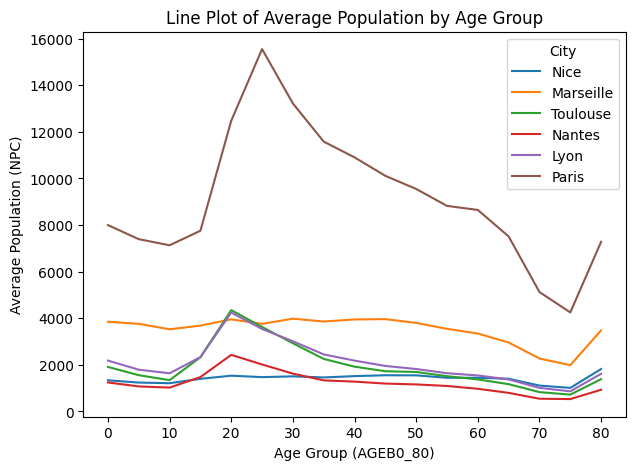

In [ ]:
#Here we present Line Plot of Average Population by Age Group

# List of cities to compare
cities_to_compare = ['Paris', 'Marseille', 'Lyon', 'Toulouse', 'Nice', 'Nantes']

# Filter population data for the selected cities
selected_population_data = ppl[ppl['LIBGEO'].isin(cities_to_compare)]

# Create line plots for average population across age groups

plt.figure(figsize=(7,5))
sns.lineplot(data=selected_population_data, x='AGEB0_80', y='NPC', hue='LIBGEO', ci=None, palette='tab10')
plt.title("Line Plot of Average Population by Age Group")
plt.xlabel("Age Group (AGEB0_80)")
plt.ylabel("Average Population (NPC)")
plt.legend(title="City", loc='upper right')

plt.show()




In [ ]:
#merge nts and ppl datasets
m_salary_ppl = pd.merge(nts, ppl, on='CODGEO')

# Prediction on Regions_merged_data.csv

In [ ]:

#regions Merged with salary
regions_m =pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/Regions_merged_data.csv')

regions_m.info()

In [ ]:
features = regions_m.drop('avg', axis=1)
target = regions_m['avg']


In [ ]:
#We perform one-hot encoding for the 'Region_Name'
from sklearn.preprocessing import OneHotEncoder

# Create an instance of the OneHotEncoder with 'handle_unknown' set to 'ignore'
oneh = OneHotEncoder(handle_unknown='ignore')

# Fit and transform the 'Region_Name' column for the training data
X_train_encoded = oneh.fit_transform(X_train[['Region_Name']])

# Transform the 'Region_Name' column for testing data
X_test_encoded = oneh.transform(X_test[['Region_Name']])


In [ ]:
# we do standardize for the avg salary
scaler = StandardScaler()
regions_m['avg'] = scaler.fit_transform(regions_m[['avg']])

In [ ]:
#we standardize the 'NPC' column
scaler = StandardScaler()
regions_m['NPC'] = scaler.fit_transform(regions_m[['NPC']])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Fit the model on the training data
linear_reg_model.fit(X_train_encoded, y_train)

# Make predictions
linear_reg_predictions = linear_reg_model.predict(X_test_encoded)


In [ ]:
print('Coefficient of determination of the model on the train set :', linear_reg_model.score(X_train_encoded, y_train))
print('Coefficient of determination of the model on the test set', linear_reg_model.score(X_test_encoded, y_test))

# the result shows that there is no coefficiency at all and there is a proble with the features or model


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_regressor = RandomForestRegressor(random_state=42)

# Fit the model on the training data
rf_regressor.fit(X_train_encoded, y_train)

# Make predictions
rf_predictions = rf_regressor.predict(X_test_encoded)



In [ ]:
print('Coefficient of determination of the Random Forest model on the train set:', rf_regressor.score(X_train_encoded, y_train))
print('Coefficient of determination of the Random Forest model on the test set:', rf_regressor.score(X_test_encoded, y_test))
## the result shows that there is no coefficiency at all and there is a proble with the features or model


# Test of prediction

In [ ]:

#merge nts and ppl datasets
m_salary_ppl = pd.merge(nts, ppl, on='CODGEO')
m_salary_ppl.info()

In [ ]:
rps = regions_m.merge(m_salary_ppl, on='avg', how='inner')
# Identify duplicate columns
# Create a list of duplicate column names
duplicates = [ 'Unnamed: 0', 'CODGEO', 'LIBGEO_x', 'MOCH', 'AGEB0_80',  'NPC_y']

# Drop the duplicate columns
rps = rps.drop(columns=duplicates)

rps.info()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


needed_columns = [
    'Region_Name',  'executive', 'middle_manager', 'employee',
    'worker','SEXE', 'NPC_x'
]

# Define target and features
target = rps['avg']
features = rps[needed_columns]

# Encode 'Region_Name' as dummy variables
features = pd.get_dummies(features, columns=['Region_Name'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize the model ofRandom Forest Regressor and train it
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# do predictions
predictions = rf_model.predict(X_test)


# Evaluate the model

print('Coefficient  of the Random Forest model on the train set:',rf_model.score(X_train, y_train))
print('Coefficient  of the Random Forest model on the test set:',rf_model.score(X_test, y_test))




In [ ]:
# Try to find out if there are important features that we can use for prediction
# Compute the correlation matrix
corr_matrix = rps.corr()

# Create a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Selected Columns')
plt.show()


In [ ]:
### Why it reads the rows of the column region name ??!!!################################################
# Initialize and train
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Match feature importances with feature names
feature_names = X_train.columns

# Create a dataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort  by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print
print(feature_importance_df)

#  Prediction

In [ ]:
sdata=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/firms_salary.csv')
sdata.info()

In [ ]:
print(sdata.columns)


In [ ]:
#Random Forest model test

#we feed the file of data set to make the test:
sdata=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/firms_salary.csv')


# Create dummy variables for 'DEP' and 'SEXE'
sdata = pd.get_dummies(sdata, columns=['DEP'], drop_first=True)


# Define features
feature_columns = [
    'Total businesses in the city',
    'businesses of unknown or zero size',
    '1 to 5 employees',
    '6 to 9 employees',
    '10 to 19 employees',
    '20 to 49 employees',
    '50 to 99 employees',
    '100 to 199 employees',
    '200 to 499 employees',
    '>500 employees',
    'avg_18',
    'avg_26',
    'avg_51'
]
# Targests that we will take
target_columns = ['18_f', '26_f', '51_f', '18_m', '26_m', '51_m']

features = sdata[feature_columns]
target = sdata[target_columns]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Make predictions
predictions = rf_model.predict(X_test)

# Evaluate the model
print('Coefficient  of the Random Forest model on train set:',rf_model.score(X_train, y_train))
print('Coefficient  of the Random Forest model on test set:',rf_model.score(X_test, y_test))

# Using Mean Squared error to evaluate the error difference between prediction.
mse = mean_squared_error(y_test, predictions)

print('Mean Squared Error:', mse)
'''
The training set performed 97% of the variance in the training data. this indicates a strong fit to the training set.
 Where the test set performed  80% that has reasonably good generalization to the unseen data.
 Overall, the system can predict the salary averages based on the provided features.
 Mean squared error has 30%
 '''

In [ ]:
# Cross-validation for Random Forest

# Define X and y
X = features
y = target

# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestRegressor()

# Perform cross-validation for Random Forest
rf_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("Random Forest Cross-Validation R2 Mean:", rf_scores.mean())
print("Random Forest Cross-Validation R2 Standard Deviation:", rf_scores.std())

'''
By doing the cross validation we got 81% of the mean R-squared that can explain variance in the target variable,
and by looking for at the standard deviation is about 0.024 the lowest showing that the
the model is performing well.

'''

In [ ]:
# Create the matrix of features and target
X = sdata[feature_columns]
y = sdata[target_columns]

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X, y)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Display feature importances
print("Random Forest Feature Importances:")
for feature, importance in zip(feature_columns, feature_importances):
    display(f"{feature}: {importance:.3f}")

In [ ]:
# Create the matrix of features and target
X = sdata[feature_columns]
y = sdata[target_columns]

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X, y)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame to display feature importances
importance_df = pd.DataFrame({'Feature': feature_columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display feature importances
print("Random Forest Feature Importances:")
display(importance_df)

'''
As we can see the first 3 are the highest features ,
 so for optimizing the model we have considered
 the top 4 features and we removed the rest of
  the columns to make it lighter .

'''

In [ ]:
#Random Forest model test after optimizing

#we feed the file of data set to make the test:
sdata=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/firms_salary.csv')


# Create dummy variables for 'DEP' and 'SEXE'
sdata = pd.get_dummies(sdata, columns=['DEP'], drop_first=True)


# Define features
feature_columns = [
    'Total businesses in the city',
    'avg_18',
    'avg_26',
    'avg_51'
]
# Targests that we will take
target_columns = ['18_f', '26_f', '51_f', '18_m', '26_m', '51_m']

features = sdata[feature_columns]
target = sdata[target_columns]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Make predictions
predictions = rf_model.predict(X_test)

# Evaluate the model
print('Coefficient  of the Random Forest model on train set:',rf_model.score(X_train, y_train))
print('Coefficient  of the Random Forest model on test set:',rf_model.score(X_test, y_test))

# Using Mean Squared error to evaluate the error difference between prediction.
mse = mean_squared_error(y_test, predictions)

print('Mean Squared Error:', mse)




In [ ]:
# Evaluate the model
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)
# Create a bar chart
scores = {'Dataset': ['Train', 'Test'], 'R-squared': [train_score, test_score]}
scores_df = pd.DataFrame(scores)

plt.figure(figsize=(8, 6))
sns.barplot(x='Dataset', y='R-squared', data=scores_df)
#do the title
plt.title('Random Forest Performance')
plt.ylim(0, 1)
plt.show()

In [ ]:
# Linear Regression


#we feed the file of data set to make the test:
sdata=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/firms_salary.csv')



# Create dummy variables for 'DEP'
sdata = pd.get_dummies(sdata, columns=['DEP'], drop_first=True)

# Define features
feature_columns = [
    'Total businesses in the city',
    'businesses of unknown or zero size',
    '1 to 5 employees',
    '6 to 9 employees',
    '10 to 19 employees',
    '20 to 49 employees',
    '50 to 99 employees',
    '100 to 199 employees',
    '200 to 499 employees',
    '>500 employees',
    'avg_18',
    'avg_26',
    'avg_51'
]
# Targets that we will take
target_columns = ['18_f', '26_f', '51_f', '18_m', '26_m', '51_m']

features = sdata[feature_columns]
target = sdata[target_columns]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
predictions = lr_model.predict(X_test)


# Evaluate the model on the training set and test set
print('Coefficient Linear Regression model on  train set:', lr_model.score(X_train, y_train))
print('Coefficient Linear Regression model on  test set:', lr_model.score(X_test, y_test))

# Evaluate the model with mean square error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)

# Print the results
print('Mean Squared Error:', mse)

print('\n')

'''
The training set performed 85% of the variance in the training data. this indicates a strong fit to the training set.
 Where the test set performed 84% that has reasonably good generalization to the unseen data.
 Overall, the system can predict the salary averages based on the provided features.
 By using the mean square error values 25%.
'''


In [ ]:
#Cross-validation for Linear Regression

# Define X and y
X = features
y = target

# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Perform cross-validation for Linear Regression
lr_scores = cross_val_score(lr_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("Linear Regression Cross-Validation R2 Mean:", lr_scores.mean())
print("Linear Regression Cross-Validation R2 Standard Deviation:", lr_scores.std())

print('\n')

'''
By doing the cross validation we got 80% of the mean R-squared that can explain variance in the target variable,
and by looking for at the standard deviation is about 0.052 which is higher than Random Forest
the model , so we can say that Random Forest has better result than Linear Regression .


'''

In [ ]:
# Calculate feature importance for Linear Regression (based on coefficients)
lr_importances = lr_model.coef_
print("\nLinear Regression Coefficients:")
for feature, importance in zip(feature_columns, lr_importances[0]):
    print(f"{feature}: {importance:.4f}")
'''
we can see the we have many which has negative results ,
so all those we will take them out inorder to optimize the
 model and we will check the results .
'''

In [ ]:
#Linear Regression model test after optimizing


#we feed the file of data set to make the test:
sdata=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/firms_salary.csv')



# Create dummy variables for 'DEP'
sdata = pd.get_dummies(sdata, columns=['DEP'], drop_first=True)

# Define features
feature_columns = [
    'Total businesses in the city',
    'businesses of unknown or zero size',
    '200 to 499 employees',
    '>500 employees',
    'avg_18',
    'avg_26',
    'avg_51'
]
# Targets that we will take
target_columns = ['18_f', '26_f', '51_f', '18_m', '26_m', '51_m']

features = sdata[feature_columns]
target = sdata[target_columns]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
predictions = lr_model.predict(X_test)


# Evaluate the model on the training set and test set
print('Coefficient Linear Regression model on  train set:', lr_model.score(X_train, y_train))
print('Coefficient Linear Regression model on  test set:', lr_model.score(X_test, y_test))

# Evaluate the model with mean square error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)

# Print the results
print('Mean Squared Error:', mse)

'''
conclusion:
After optimizing the model by removing the negative columns ,
 we can see the model has almost the same results ,
  it's true the there is no changes in results however we managed
   to make the model lighter by removing unnecessary columns.

'''

In [ ]:
# Evaluate the model on the training set and test set
train_score = lr_model.score(X_train, y_train)
test_score = lr_model.score(X_test, y_test)

# Create a DataFrame for visualization
scores = {'Dataset': ['Train', 'Test'], 'R-squared': [train_score, test_score]}
scores_df = pd.DataFrame(scores)

# Define a custom color palette for the bars
colors = ['lightblue', 'lightcoral']

# Create a bar chart with custom colors
plt.figure(figsize=(8, 6))
sns.barplot(x='Dataset', y='R-squared', data=scores_df, palette=colors)
#do the title
plt.title('Linear Regression Performance')
plt.ylim(0, 1)  # Set the y-axis limit to 0-1 for R-squared values
plt.show()

In [ ]:
'''
 By comperaing the bothe models we will consider Linear Regression model , both models has high coefficiency
Random forest is higher , however the Linear Regression model has lower mean error which means it predicts the target values with less error.

'''

In [ ]:
#XGBoost Regressor

#we feed the file of data set to make the test:
sdata=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/firms_salary.csv')



# Define your features and targets
feature_columns = [
    'Total businesses in the city',
    'businesses of unknown or zero size',
    '1 to 5 employees',
    '6 to 9 employees',
    '10 to 19 employees',
    '20 to 49 employees',
    '50 to 99 employees',
    '100 to 199 employees',
    '200 to 499 employees',
    '>500 employees',
    'avg_18',
    'avg_26',
    'avg_51'
]
target_columns = ['18_f', '26_f', '51_f', '18_m', '26_m', '51_m']

features = sdata[feature_columns]
target = sdata[target_columns]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

# Make predictions
predictions = xgb_model.predict(X_test)

# Evaluate the model
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)

# Calculate mean squared error
mse = mean_squared_error(y_test, predictions)

# Print the results
print('Coefficient of the XGBoost on train set:', train_score)
print('Coefficient of the XGBoost on test set:', test_score)
print('Mean Squared Error:', mse)
print('\n')

'''
By using Gx boost regression we find out that it has high fit to the training data
learned from training data which has 98% of the different types of salary averages.
which is close to 100%.

And for the test set it's lower than the train test, however it's high to predict the unseen data.
which can predict salary averages with accuracy of 87% when we present new unseen data
that it comes with reasonable accuracy.

By seeing the mean square is showing that the error rate to be missed is around 25%
that can be good for business to make decisions.

'''


In [ ]:
#XGBoost Cross-Validation

# Define X and y
X = features
y = target

# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the XGBoost model
xgb_model = XGBRegressor()

# Perform cross-validation for XGBoost
xgb_scores = cross_val_score(xgb_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("XGBoost Cross-Validation R2 Mean:", xgb_scores.mean())
print("XGBoost Cross-Validation R2 Standard Deviation:", xgb_scores.std())
print('\n')

'''
By doing the cross validation we got 80% of the mean R-squared that can explain variance in the target variable,
and by looking for at the standard deviation is about 0.096 which is higher than Random Forest
the model , so we can say that Random Forest has better result than Linear Regression .

'''

In [ ]:
# Create and train the XGBoost model
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

# Calculate feature importance for XGBoost
xgb_importances = xgb_model.get_booster().get_score()
print("\nXGBoost Feature Importances:")
for feature, importance in xgb_importances.items():
    print(f"{feature}: {importance}")
'''
we can see there are 3 features which are very low
100 to 199 employees: 663.0
 200 to 499 employees: 497.0
 >500 employees: 227.0
we will remove them to optimizing the model and we will compare the results .

'''

In [ ]:
#XGBoost model test after optimizing

#we feed the file of data set to make the test:
sdata=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/firms_salary.csv')



# Define your features and targets
feature_columns = [
    'Total businesses in the city',
    'businesses of unknown or zero size',
    '1 to 5 employees',
    '6 to 9 employees',
    '10 to 19 employees',
    '20 to 49 employees',
    '50 to 99 employees',
    'avg_18',
    'avg_26',
    'avg_51'
]
target_columns = ['18_f', '26_f', '51_f', '18_m', '26_m', '51_m']

features = sdata[feature_columns]
target = sdata[target_columns]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

# Make predictions
predictions = xgb_model.predict(X_test)

#################################################
# Evaluate the model
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)

# Calculate mean squared error
mse = mean_squared_error(y_test, predictions)

# Print the results
print('Coefficient of the XGBoost on train set:', train_score)
print('Coefficient of the XGBoost on test set:', test_score)

print('Mean Squared Error:', mse)
print('\n')
###############################

# Define X and y
X = features
y = target
# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for XGBoost
xgb_scores = cross_val_score(xgb_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("XGBoost Cross-Validation R2 Mean:", xgb_scores.mean())
print("XGBoost Cross-Validation R2 Standard Deviation:", xgb_scores.std())
print('\n')


# Final predictions

In [ ]:
#we feed the file of data set to make the test:
dfn=pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/merged_cleansed_new.csv')
dfn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5130 entries, 0 to 5129
Data columns (total 47 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          5130 non-null   int64  
 1   CODGEO                              5130 non-null   object 
 2   Region_Name                         5130 non-null   object 
 3   Regional_Capital                    5130 non-null   object 
 4   Con_Number                          5130 non-null   int64  
 5   Commune_Name                        5130 non-null   object 
 6   Postal_Codes                        5130 non-null   object 
 7   INSEE_Code                          5130 non-null   int64  
 8   Distance                            5130 non-null   float64
 9   LIBGEO_x                            5130 non-null   object 
 10  REG                                 5130 non-null   int64  
 11  DEP                                 5130 no

In [ ]:
# Load the dataset
dfn = pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/merged_cleansed_new.csv')
# Define the columns to keep
columns_to_keep = [
    'CODGEO', #city number
    'Con_Number',
    'LIBGEO_x',
    'Postal_Codes',
    'Total businesses in the city',
    'businesses of unknown or zero size',
    '1 to 5 employees',
    '6 to 9 employees',
    '10 to 19 employees',
    '20 to 49 employees',
    '50 to 99 employees',
    '100 to 199 employees',
    '200 to 499 employees',
    '>500 employees',
    'executive_f',
    'middle_manager_f',
    'employee_f',
    'worker_f',
    'executive_m',
    'middle_manager_m',
    'employee_m',
    'worker_m',
    '18_f',
    '26_f',
    '51_f',
    '18_m',
    '26_m',
    '51_m',
    'avg'
]


# Drop unnecessary columns
dfn = dfn[columns_to_keep]

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'CODGEO' column
dfn['CODGEO'] = label_encoder.fit_transform(dfn['CODGEO'])
dfn['LIBGEO_x'] = label_encoder.fit_transform(dfn['LIBGEO_x'])
dfn['Postal_Codes'] = label_encoder.fit_transform(dfn['Postal_Codes'])

#convert to int
dfn['CODGEO'] = dfn['CODGEO'].astype(int)
dfn['LIBGEO_x'] = dfn['LIBGEO_x'].astype(int)
dfn['Postal_Codes'] = dfn['Postal_Codes'].astype(int)

In [ ]:
min_avg = dfn['avg'].min()
max_avg = dfn['avg'].max()
print("Minimum avg value:", min_avg)
print("Maximum avg value:", max_avg)

Minimum avg value: 10.2
Maximum avg value: 43.3


In [ ]:
dfn.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5130 entries, 0 to 5129
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   CODGEO                              5130 non-null   int64  
 1   Con_Number                          5130 non-null   int64  
 2   LIBGEO_x                            5130 non-null   int64  
 3   Postal_Codes                        5130 non-null   int64  
 4   Total businesses in the city        5130 non-null   int64  
 5   businesses of unknown or zero size  5130 non-null   int64  
 6   1 to 5 employees                    5130 non-null   int64  
 7   6 to 9 employees                    5130 non-null   int64  
 8   10 to 19 employees                  5130 non-null   int64  
 9   20 to 49 employees                  5130 non-null   int64  
 10  50 to 99 employees                  5130 non-null   int64  
 11  100 to 199 employees                5130 no

In [ ]:
dfn.shape

In [ ]:
dfn.info()

In [ ]:
#Random Forest model test


# Define features
feature = dfn.drop('avg', axis=1)

# Target variable
target= dfn['avg']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)


# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Make predictions
predictions = rf_model.predict(X_test)

# Evaluate the model
r2_train = round(rf_model.score(X_train, y_train), 3)
r2_test = round(rf_model.score(X_test, y_test), 3)
print('(R2) on train set:', r2_train)
print('(R2) on test set:', r2_test)
# Using Mean Squared Error to evaluate the error difference between predictions
mse = round(mean_squared_error(y_test, predictions), 3)
print('Mean Squared Error:', mse)

'''
The training set performed 99% of the variance in the training data. This indicates a strong fit to the training set.
Where the test set performed 99% that has reasonably good generalization to the unseen data.
Overall, the system can predict the salary averages based on the provided features.
Mean squared error has 0.044 which is very low.
However, this was before taking out the extra columns and do the Feature importances
to check which feature has high correlation.
'''


(R2) on train set: 0.998
(R2) on test set: 0.993
Mean Squared Error: 0.045


'\nThe training set performed 99% of the variance in the training data. This indicates a strong fit to the training set.\nWhere the test set performed 99% that has reasonably good generalization to the unseen data.\nOverall, the system can predict the salary averages based on the provided features.\nMean squared error has 0.044 which is very low.\nHowever, this was before taking out the extra columns and do the Feature importances \nto check which feature has high correlation.\n'

In [ ]:
# Cross-validation for Random Forest

# Define X and y
X = feature
y = target

# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestRegressor()

# Perform cross-validation for Random Forest
rf_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("K-Fold Cross-Validation R2 Mean:", rf_scores.mean())
print("K-Fold Cross-Validation R2 Standard Deviation:", rf_scores.std())

'''

'''

K-Fold Cross-Validation R2 Mean: 0.9908792489775436
K-Fold Cross-Validation R2 Standard Deviation: 0.003256593179402062


'\n\n'

In [ ]:

# Get feature importances
feature_importances = rf_model.feature_importances_

# Display feature importances
print("Random Forest Feature Importances:")
for feature, importance in zip(features, feature_importances):
    display(f"{feature}: {importance:.3f}")

In [ ]:
# Get feature importances
from scipy.stats import pearsonr

# Initialize a dictionary to store the correlation coefficients
correlations = {}

# Iterate through each feature column and calculate the Pearson correlation with the target 'avg'
for feature_column in dfn.columns:
    if feature_column != 'avg':
        r, _ = pearsonr(dfn[feature_column], dfn['avg'])
        correlations[feature_column] = r

# Print the calculated correlation coefficients
for feature, correlation in correlations.items():
    print(f" {feature}: {correlation:.3f}")


'''
Here we can see the features that is close to 1 and we will take that ,
We will take all the features that are higher than 0.200 and we will remove all features with low and we will check what will be the results .


'''



 CODGEO: 0.215
 Con_Number: 0.083
 LIBGEO_x: 0.018
 Postal_Codes: 0.217
 Total businesses in the city: 0.067
 businesses of unknown or zero size: 0.068
 1 to 5 employees: 0.059
 6 to 9 employees: 0.062
 10 to 19 employees: 0.063
 20 to 49 employees: 0.070
 50 to 99 employees: 0.076
 100 to 199 employees: 0.085
 200 to 499 employees: 0.099
 >500 employees: 0.116
 executive_f: 0.683
 middle_manager_f: 0.781
 employee_f: 0.848
 worker_f: 0.686
 executive_m: 0.802
 middle_manager_m: 0.671
 employee_m: 0.742
 worker_m: 0.818
 18_f: 0.599
 26_f: 0.953
 51_f: 0.911
 18_m: 0.403
 26_m: 0.983
 51_m: 0.963


'\nHere we can see the features that is close to 1 and we will take that ,\nWe will take all the features that are higher than 0.200 and we will remove all features with low and we will check what will be the results .\n\n\n'

In [ ]:
#Recursive Feature Elimination (RFE)

# Initialize the RFE model with the RandomForestRegressor
rfe = RFE(estimator=rf_model, n_features_to_select=15)

# Fit the RFE model to the data
rfe.fit(X_train_scaled, y_train)

# Get the selected features
selected_features = [feature.columns[i] for i, ranking in enumerate(rfe.ranking_) if ranking == 1]

# Print the selected features
print("Selected Features:", selected_features)






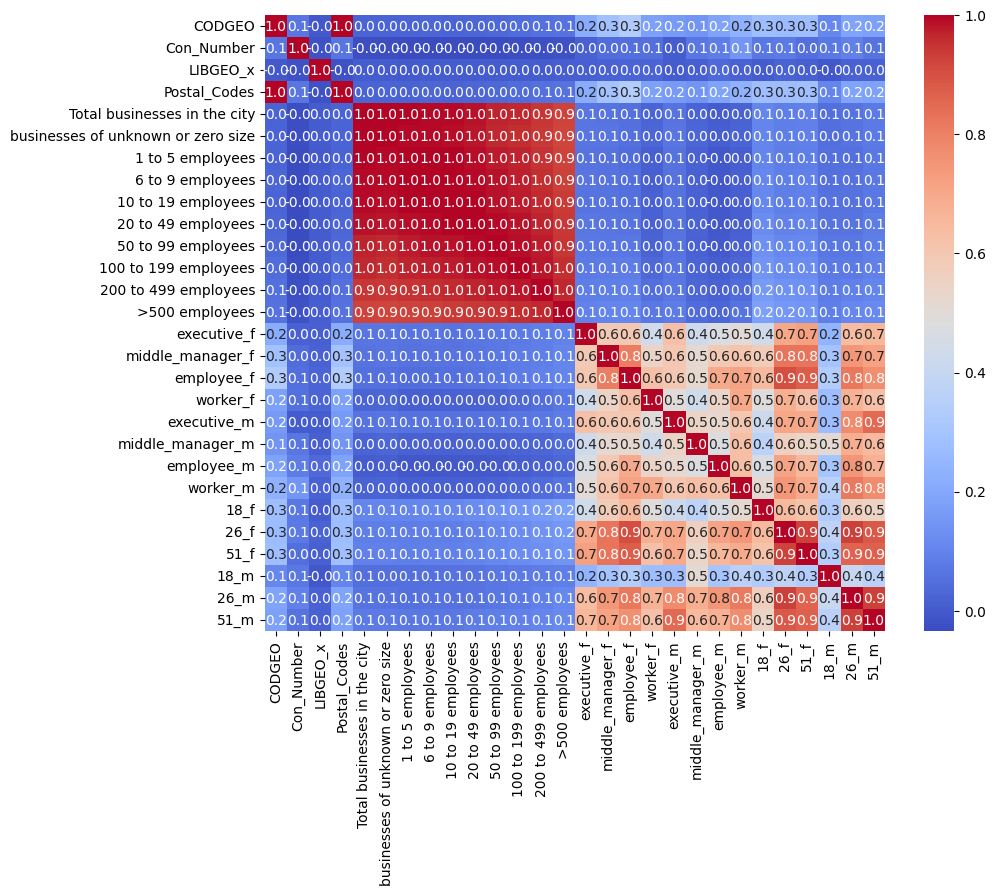

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression
# Define features
feature = dfn.drop('avg', axis=1)

# Target variable
target= dfn['avg']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the feature data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create SelectKBest instance
k_best = SelectKBest(score_func=f_regression, k='all')

# Fit the SelectKBest model to the data and transform it
X_train_kbest = k_best.fit_transform(X_train_scaled, y_train)

# Get the selected feature indices
selected_feature_indices = k_best.get_support(indices=True)

# Get the original feature names for the selected features
selected_feature_names = [feature[i] for i in feature]

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(feature.corr(), annot=True, cmap='coolwarm', fmt=".1f")
plt.show()

In [ ]:
###################################################################################

In [ ]:
# Load the dataset
dff = pd.read_csv('/content/drive/MyDrive/Project_(french_industry)/merged_cleansed_new.csv')
# Define the columns to keep
columns_to_keep = [
    'CODGEO', #city number
    'Postal_Codes',
    'executive_f',
    'middle_manager_f',
    'employee_f',
    'worker_f',
    'executive_m',
    'middle_manager_m',
    'employee_m',
    'worker_m',
    '18_f',
    '26_f',
    '51_f',
    '18_m',
    '26_m',
    '51_m',
    'avg'
]


# Drop unnecessary columns
dff = dff[columns_to_keep]

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'CODGEO' column
dff['CODGEO'] = label_encoder.fit_transform(dff['CODGEO'])
dff['Postal_Codes'] = label_encoder.fit_transform(dff['Postal_Codes'])
#convert to int
dff['CODGEO'] = dff['CODGEO'].astype(int)
dff['Postal_Codes'] = dff['Postal_Codes'].astype(int)

In [ ]:
#Random Forest model test


# Define features
feature = dff.drop('avg', axis=1)

# Target variable
target= dff['avg']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)


# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Make predictions
predictions = rf_model.predict(X_test)

# Evaluate the model
print('(R2) on train set:', rf_model.score(X_train, y_train))
print('(R2) on test set:', rf_model.score(X_test, y_test))

# Using Mean Squared Error to evaluate the error difference between predictions
mse = mean_squared_error(y_test, predictions)
print('Mean Squared Error:', mse)



(R2) on train set: 0.9984372105140449
(R2) on test set: 0.9928582329226664
Mean Squared Error: 0.046114975633528246


In [ ]:
# Cross-validation for Random Forest

# Define X and y
X = feature
y = target

# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Random Forest model
rf_model = RandomForestRegressor()

# Perform cross-validation for Random Forest
rf_scores = cross_val_score(rf_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("K-Fold RF Cross-Validation R2 Mean:", rf_scores.mean())
print("K-Fold RF Cross-Validation R2 Standard Deviation:", rf_scores.std())

K-Fold RF Cross-Validation R2 Mean: 0.9911776840714717
K-Fold RF Cross-Validation R2 Standard Deviation: 0.003250505019625541


100%|===================| 1021/1026 [00:57<00:00]       

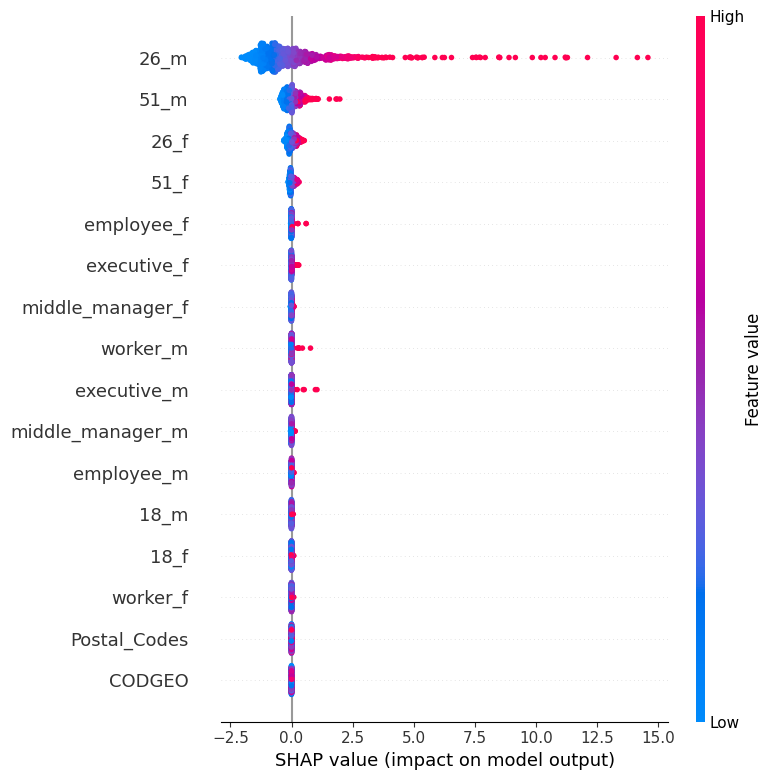

In [ ]:
# Define features
feature = dff.drop('avg', axis=1)

# Target variable
target = dff['avg']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Create a SHAP explainer for your model
explainer = shap.Explainer(rf_model, X_train)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Plot the summary plot
shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=False)
plt.show()

In [ ]:
# Linear Regression

# Define features
feature = dff.drop('avg', axis=1)

# Target variable
target= dff['avg']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
predictions = lr_model.predict(X_test)


# Evaluate the model on the training set and test set
print('(R2) on train set:', lr_model.score(X_train, y_train))
print('(R2) on test set:', lr_model.score(X_test, y_test))


mse = mean_squared_error(y_test, predictions)

# Print the results
print('Mean Squared Error:', mse)



(R2) on train set: 0.9940621717674653
(R2) on test set: 0.9951909726436142
Mean Squared Error: 0.03105228397388423


In [ ]:

# Define X and y
X = feature
y = target


# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for Linear Regression
lr_scores = cross_val_score(lr_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("K-Fold LR Cross-Validation R2 Mean:", lr_scores.mean())
print("K-Fold LR Cross-Validation R2 Standard Deviation:", lr_scores.std())

K-Fold LR Cross-Validation R2 Mean: 0.9941605987642991
K-Fold LR Cross-Validation R2 Standard Deviation: 0.0008369185180293782


In [ ]:
#XGBoost Regressor

# Define features
feature = dff.drop('avg', axis=1)

# Target variable
target= dff['avg']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

# Make predictions
predictions = xgb_model.predict(X_test)

# Evaluate the model
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)

# Calculate mean squared error
mse = mean_squared_error(y_test, predictions)

# Print the results
print('(R2) on train set:', train_score)
print('(R2) on test set:', test_score)
print('Mean Squared Error:', mse)
print('\n')


(R2) on train set: 0.9995715047706464
(R2) on test set: 0.9908586456687488
Mean Squared Error: 0.05902647449550887




In [ ]:
#XGBoost Cross-Validation

# Define X and y
X = feature
y = target

# Create a K-Fold cross-validator with 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the XGBoost model
xgb_model = XGBRegressor()

# Perform cross-validation for XGBoost
xgb_scores = cross_val_score(xgb_model, X, y, cv=kfold, scoring='r2')

# Calculate and print the mean and standard deviation of R2 scores
print("K-Fold XG Cross-Validation R2 Mean:", xgb_scores.mean())
print("K-Fold XG Cross-Validation R2 Standard Deviation:", xgb_scores.std())
print('\n')


K-Fold XG Cross-Validation R2 Mean: 0.9898540536373603
K-Fold XG Cross-Validation R2 Standard Deviation: 0.0025565796161924085




In [ ]:
# Compairing the 3 models to check the best
#Random Forest model test


# Define features
feature = dff.drop('avg', axis=1)
target= dff['avg']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)


#Random Forest Regressor

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Make predictions Metrics
y_pred_rf_test = rf_model.predict(X_test)
y_pred_rf_train = rf_model.predict(X_train)
# Training set
mae_rf_model_train=mean_absolute_error(y_train,y_pred_rf_train)
mse_rf_model_train = mean_squared_error(y_train,y_pred_rf_train,squared=True)
rmse_rf_model_train = mean_squared_error(y_train,y_pred_rf_train,squared=False)
# Test set
mae_rf_model_test=mean_absolute_error(y_test,y_pred_rf_test)
mse_rf_model_test = mean_squared_error(y_test,y_pred_rf_test,squared=True)
rmse_rf_model_test = mean_squared_error(y_test,y_pred_rf_test,squared=False)


#Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions Metrics
y_pred_lr_test = lr_model.predict(X_test)
y_pred_lr_train = lr_model.predict(X_train)
# Training set
mae_lr_model_train=mean_absolute_error(y_train,y_pred_lr_train)
mse_lr_model_train = mean_squared_error(y_train,y_pred_lr_train,squared=True)
rmse_lr_model_train = mean_squared_error(y_train,y_pred_lr_train,squared=False)
# Test set
mae_lr_model_test=mean_absolute_error(y_test,y_pred_lr_test)
mse_lr_model_test = mean_squared_error(y_test,y_pred_lr_test,squared=True)
rmse_lr_model_test = mean_squared_error(y_test,y_pred_lr_test,squared=False)


#XGBoost Regressor

# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

# Make predictions Metrics
y__pred_xgb_test = xgb_model.predict(X_test)
y__pred_xgb_train = xgb_model.predict(X_train)


# Training set
mae_xgb_model_train=mean_absolute_error(y_train,y__pred_xgb_train)
mse_xgb_model_train = mean_squared_error(y_train,y__pred_xgb_train,squared=True)
rmse_xgb_model_train = mean_squared_error(y_train,y__pred_xgb_train,squared=False)
# Test set
mae_xgb_model_test=mean_absolute_error(y_test,y__pred_xgb_test)
mse_xgb_model_test = mean_squared_error(y_test,y__pred_xgb_test,squared=True)
rmse_xgb_model_test = mean_squared_error(y_test,y__pred_xgb_test,squared=False)

# Creation of a dataframe to compare the metrics
data = {
    'MAE train': [mae_rf_model_train, mae_lr_model_train,mae_xgb_model_train],
    'MAE test': [mae_rf_model_test, mae_lr_model_test,mae_xgb_model_test],
    'MSE train': [mse_rf_model_train, mse_lr_model_train,mse_xgb_model_train],
    'MSE test': [mse_rf_model_test, mse_lr_model_test,mse_xgb_model_test],
    'RMSE train': [rmse_rf_model_train, rmse_lr_model_train,rmse_xgb_model_train,],
    'RMSE test': [rmse_rf_model_test, rmse_lr_model_test,rmse_xgb_model_test]
}

# DataFrame

df = pd.DataFrame(data, index=['Random Forest ', 'Linear Regression ','XGBoost Regressor'])

df.head()


,MAE train,MAE test,MSE train,MSE test,RMSE train,RMSE test
Random Forest,0.052918,0.140942,0.009197,0.046108,0.095903,0.214727
Linear Regression,0.129689,0.128471,0.036738,0.031052,0.191670,0.176217
XGBoost Regressor,0.038130,0.144859,0.002651,0.059026,0.051489,0.242954
